# 03 – Feature-Driven Analysis

**Questions answered (for all 6 features):**
- Does the feature explain when STL decomposition helps?
- Is the STL effect stronger in Low / Medium / High regimes?
- Are direct models preferable in any regime?
- Does the answer change across Low / Medium / High buckets?
- Do the same model families win for Monthly and Quarterly data within each bucket?

**Requires:** `data/master_metrics.parquet`, `data/stl_delta.parquet`, `data/features.parquet`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
DATA = Path("data")

master     = pd.read_parquet(DATA / "master_metrics.parquet")
stl_delta  = pd.read_parquet(DATA / "stl_delta.parquet")
features   = pd.read_parquet(DATA / "features.parquet")

FEATURES = [
    "feature_non_normality",
    "feature_nonlinearity",
    "feature_spectral_entropy",
    "feature_evolving_seasonality",
    "feature_structural_break_strength",
    "feature_arch_stat",
]
FEATURE_LABELS = {
    "feature_non_normality": "Non-normality (φ₁)",
    "feature_nonlinearity": "Nonlinearity (φ₂)",
    "feature_spectral_entropy": "Spectral entropy (φ₃)",
    "feature_evolving_seasonality": "Evolving seasonality (φ₄)",
    "feature_structural_break_strength": "Structural break (φ₅)",
    "feature_arch_stat": "ARCH / volatility (φ₆)",
}
BUCKET_ORDER = ["Low", "Medium", "High"]
DECOMP_LABELS = {
    "without_stl": "Direct",
    "stl_seasonal_naive": "STL–SeasonalNaive",
    "stl_model_all_components": "STL–AllComponents",
}
FAMILY_LABELS = {
    "statistical": "Statistical",
    "mlforecast": "ML",
    "neuralforecast": "Neural",
    "transformers": "Transformers",
}

print("Data loaded. Features:", features.shape, "  stl_delta:", stl_delta.shape)

Data loaded. Features: (3000, 12)   stl_delta: (2255148, 35)


## Feature Distributions

Overview of all six feature values across all selected series.

C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\228343955.py:12: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\228343955.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\228343955.py:12: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\228343955.py:12: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\228343955.py:12: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\228343955.py:12: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ip

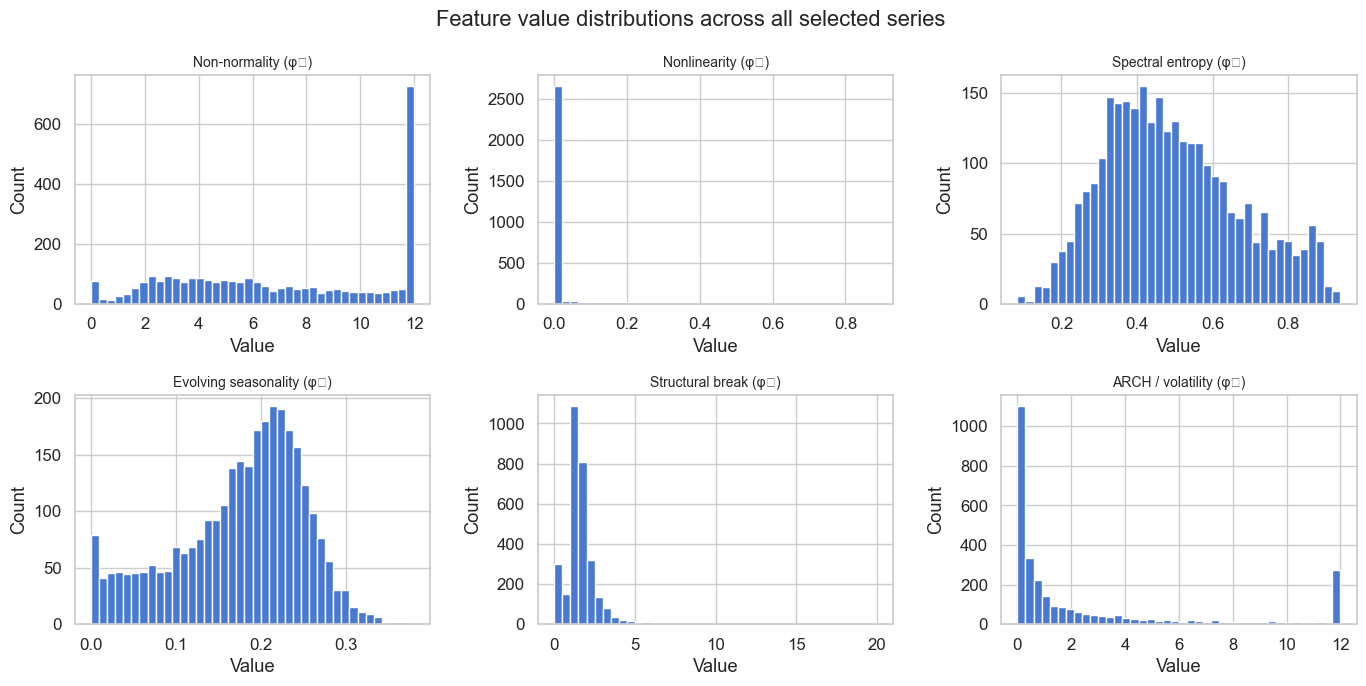

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, FEATURES):
    if feat not in features.columns:
        ax.set_visible(False)
        continue
    vals = features[feat].dropna()
    ax.hist(vals, bins=40, color=sns.color_palette("muted")[0], edgecolor="white")
    ax.set_title(FEATURE_LABELS[feat], fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
fig.suptitle("Feature value distributions across all selected series")
fig.tight_layout()
plt.savefig(DATA / "fig_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## STL Delta by Feature and Bucket

For each feature, shows the mean RelNaive delta (STL – Direct baseline) broken down by  
Low / Medium / High feature bucket. Green = STL helps, red = STL harms.

**Q: Does the feature explain when STL helps?**  
**Q: Is the STL effect stronger in Low / Medium / High regimes?**  
**Q: Are direct models preferable in any regime?**


=== Non-normality (φ₁) ===


c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1744213943.py:42: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


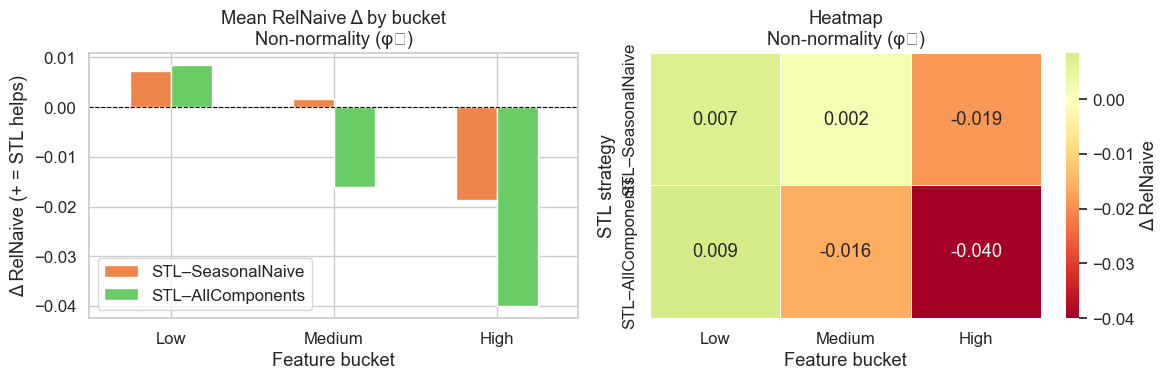

  Direct models preferred in: ['High']

=== Nonlinearity (φ₂) ===


c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1744213943.py:42: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


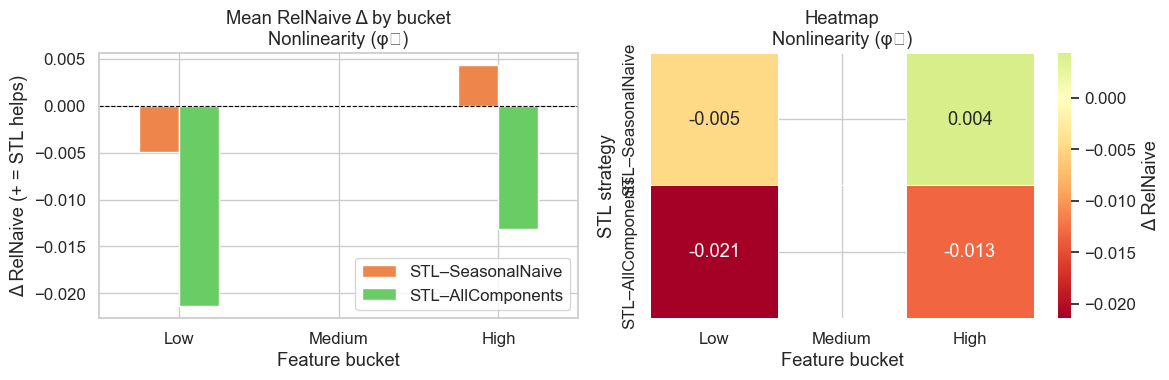

  Direct models preferred in: ['Low']

=== Spectral entropy (φ₃) ===


c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1744213943.py:42: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


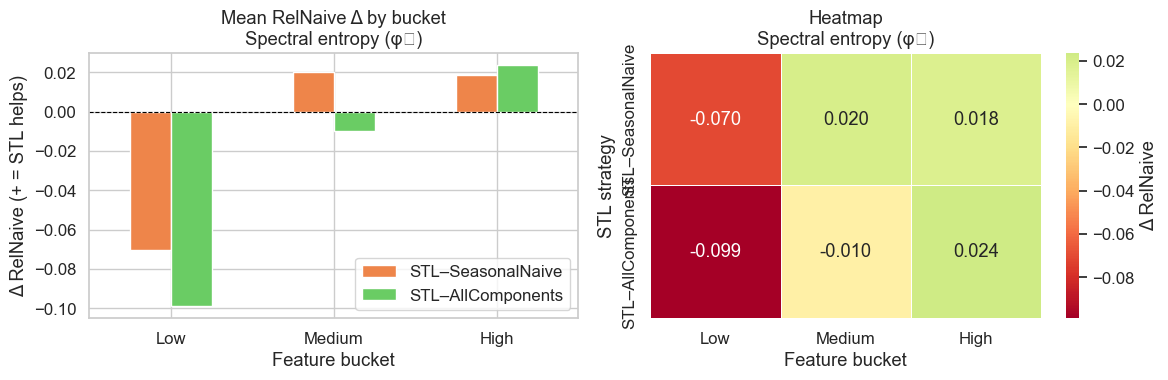

  Direct models preferred in: ['Low']

=== Evolving seasonality (φ₄) ===


c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1744213943.py:42: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


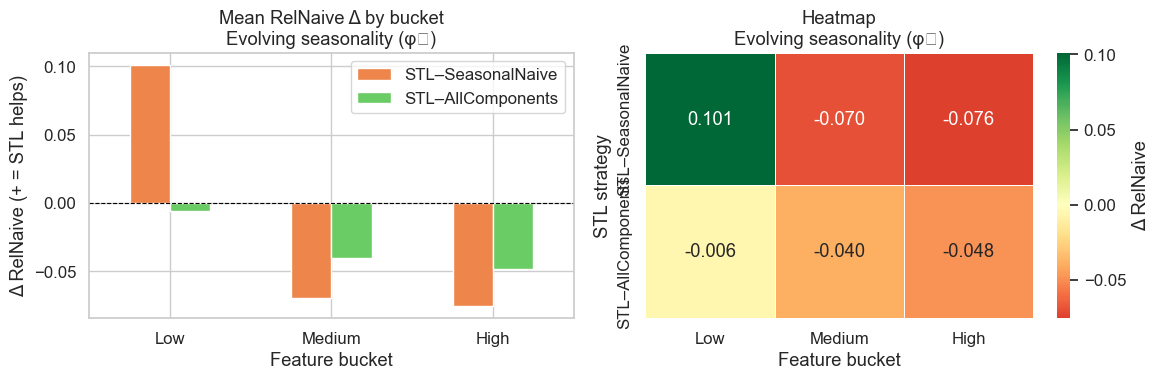

  Direct models preferred in: ['Medium', 'High']

=== Structural break (φ₅) ===


c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1744213943.py:42: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


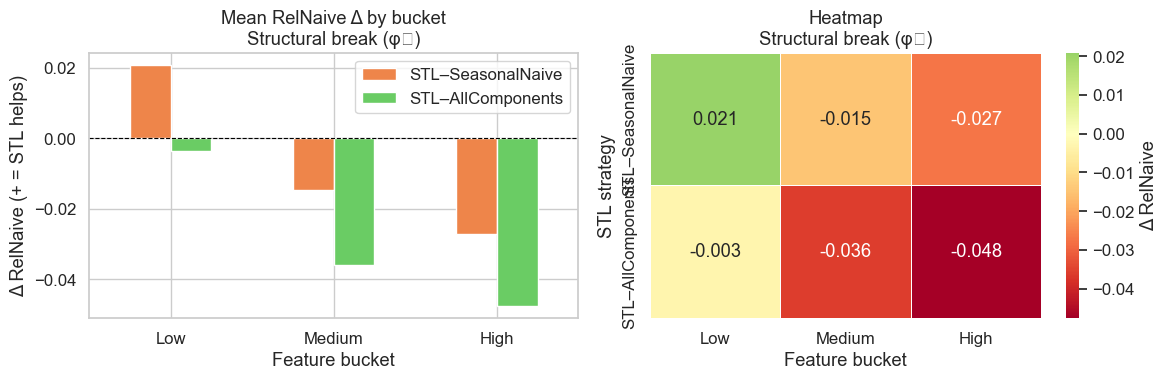

  Direct models preferred in: ['Medium', 'High']

=== ARCH / volatility (φ₆) ===


c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1744213943.py:42: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


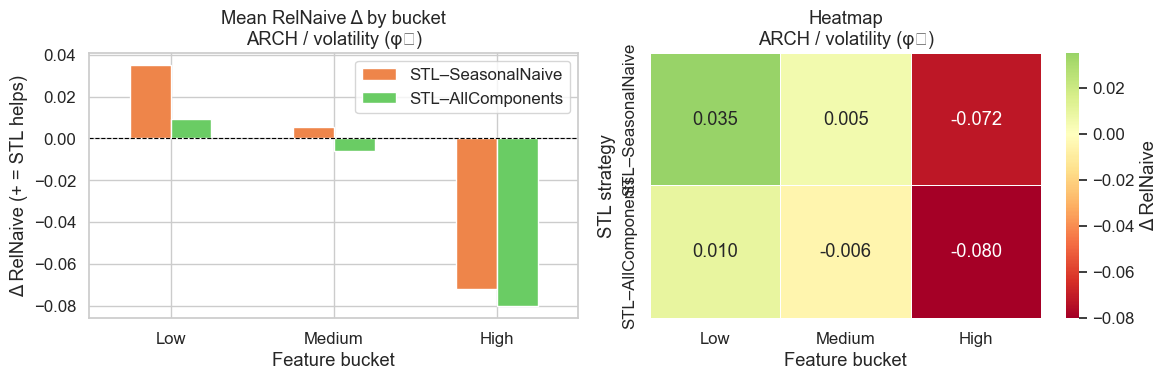

  Direct models preferred in: ['High']


In [3]:
def plot_feature_bucket_delta(stl_delta, feature_name, save_path=None):
    sub = stl_delta[stl_delta["feature_name"] == feature_name].copy()
    if sub.empty:
        print(f"No data for {feature_name}")
        return

    grp = (
        sub
        .groupby(["feature_bucket", "decomposition_method"])["rn_delta"]
        .agg(["mean", "count"])
        .reset_index()
    )
    pivot = grp.pivot(index="feature_bucket", columns="decomposition_method", values="mean")
    pivot = pivot.reindex(BUCKET_ORDER)
    stl_cols = [c for c in ["stl_seasonal_naive", "stl_model_all_components"] if c in pivot.columns]
    pivot = pivot[stl_cols]
    pivot.columns = [DECOMP_LABELS[c] for c in pivot.columns]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    pivot.plot(kind="bar", ax=axes[0], edgecolor="white",
               color=[sns.color_palette("muted")[1], sns.color_palette("muted")[2]])
    axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_title(f"Mean RelNaive Δ by bucket\n{FEATURE_LABELS[feature_name]}")
    axes[0].set_xlabel("Feature bucket")
    axes[0].set_ylabel("Δ RelNaive (+ = STL helps)")
    axes[0].tick_params(axis="x", rotation=0)

    # Heatmap
    sns.heatmap(
        pivot.T, annot=True, fmt=".3f", center=0,
        cmap="RdYlGn", linewidths=0.5, ax=axes[1],
        cbar_kws={"label": "Δ RelNaive"}
    )
    axes[1].set_title(f"Heatmap\n{FEATURE_LABELS[feature_name]}")
    axes[1].set_xlabel("Feature bucket")
    axes[1].set_ylabel("STL strategy")

    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Direct models preferable?
    direct_preferred = (pivot < 0).all(axis=1)
    if direct_preferred.any():
        print(f"  Direct models preferred in: {list(direct_preferred[direct_preferred].index)}")
    else:
        print(f"  STL or neutral in all buckets")

    return pivot


all_pivots = {}
for feat in FEATURES:
    print(f"\n=== {FEATURE_LABELS[feat]} ===")
    piv = plot_feature_bucket_delta(
        stl_delta, feat,
        save_path=DATA / f"fig_bucket_delta_{feat}.png"
    )
    if piv is not None:
        all_pivots[feat] = piv

## STL Delta by Feature, Bucket, and Frequency

**Q: Does the answer change across Low/Medium/High buckets of each feature?**  
**Q: Do the same model families win for Monthly and Quarterly data?**

c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1176563260.py:34: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(DATA / f"fig_freq_bucket_{feat}.png", dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


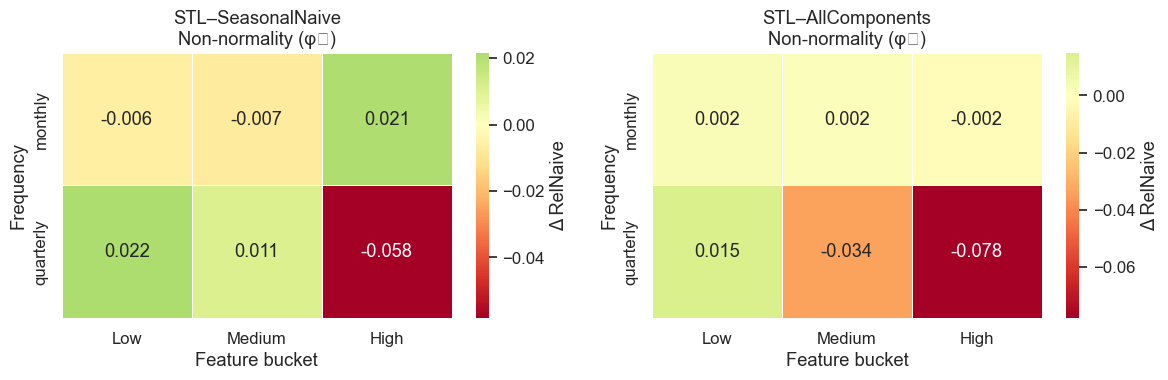

c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1176563260.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(DATA / f"fig_freq_bucket_{feat}.png", dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


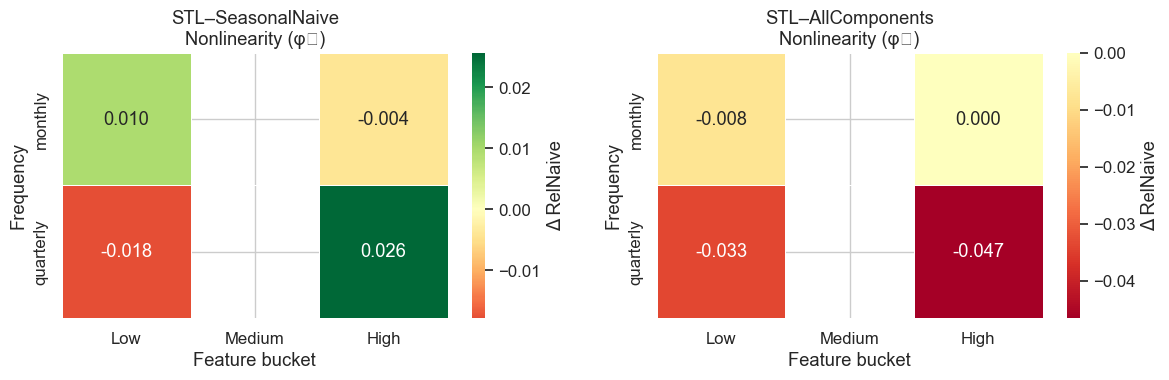

c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1176563260.py:34: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.savefig(DATA / f"fig_freq_bucket_{feat}.png", dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


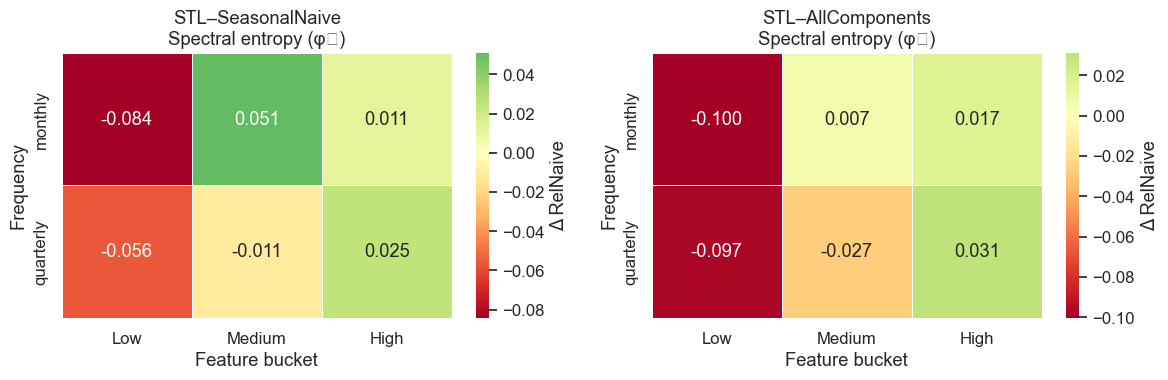

c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1176563260.py:34: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.savefig(DATA / f"fig_freq_bucket_{feat}.png", dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


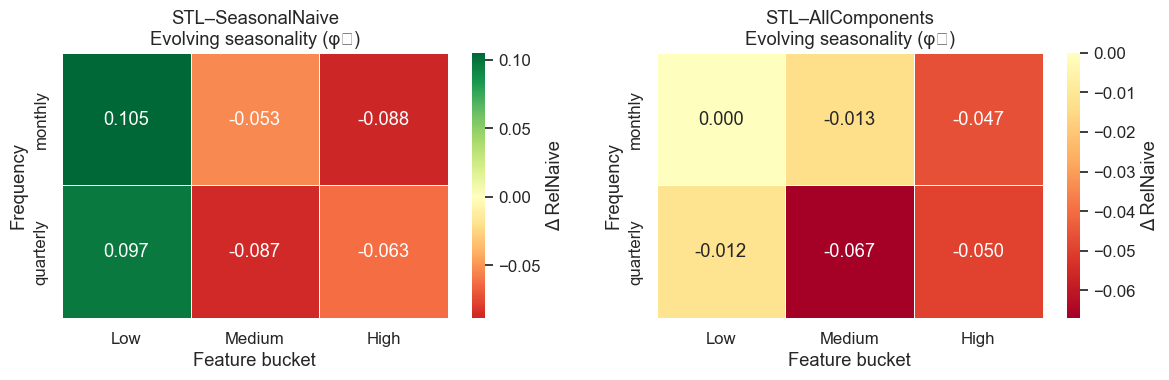

c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1176563260.py:34: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.savefig(DATA / f"fig_freq_bucket_{feat}.png", dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


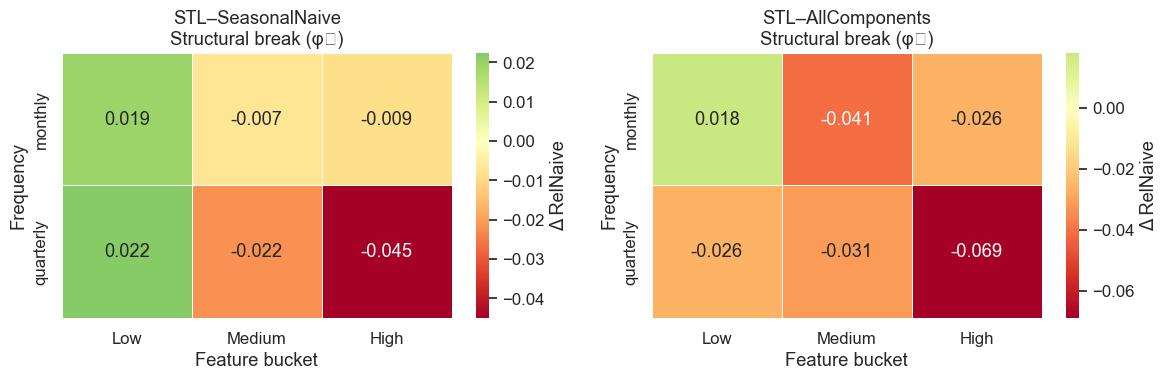

c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\1176563260.py:34: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  plt.savefig(DATA / f"fig_freq_bucket_{feat}.png", dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


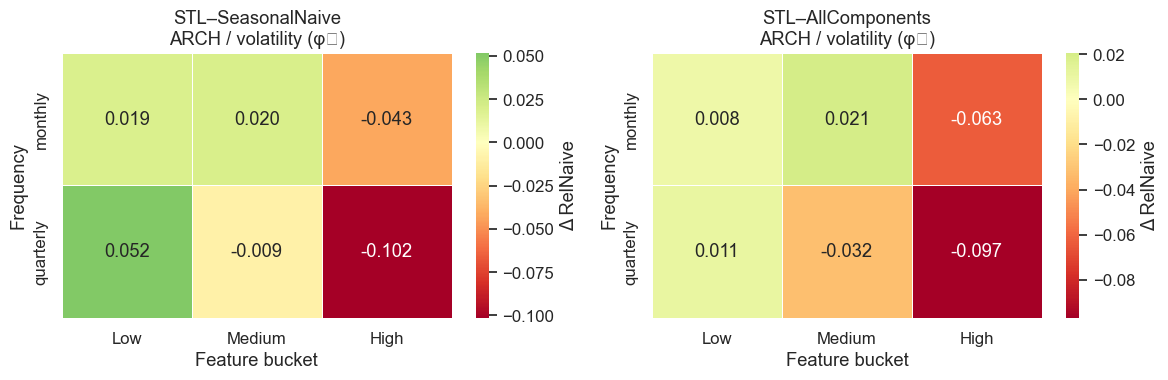

In [4]:
for feat in FEATURES:
    sub = stl_delta[stl_delta["feature_name"] == feat]
    if sub.empty:
        continue

    grp = (
        sub
        .groupby(["frequency", "feature_bucket", "decomposition_method"])["rn_delta"]
        .mean()
        .reset_index()
    )
    stl_cols = [c for c in ["stl_seasonal_naive", "stl_model_all_components"]
                if c in grp["decomposition_method"].values]
    grp = grp[grp["decomposition_method"].isin(stl_cols)]

    fig, axes = plt.subplots(1, len(stl_cols), figsize=(6 * len(stl_cols), 4))
    if len(stl_cols) == 1:
        axes = [axes]

    for ax, decomp in zip(axes, stl_cols):
        d = grp[grp["decomposition_method"] == decomp]
        pivot = d.pivot(index="feature_bucket", columns="frequency", values="rn_delta")
        pivot = pivot.reindex(BUCKET_ORDER)
        sns.heatmap(
            pivot.T, annot=True, fmt=".3f", center=0,
            cmap="RdYlGn", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Δ RelNaive"}
        )
        ax.set_title(f"{DECOMP_LABELS[decomp]}\n{FEATURE_LABELS[feat]}")
        ax.set_xlabel("Feature bucket")
        ax.set_ylabel("Frequency")

    fig.tight_layout()
    plt.savefig(DATA / f"fig_freq_bucket_{feat}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Family Winners per Feature and Bucket

Best model family per `(feature, bucket, decomposition)` by mean RelNaive.

In [5]:
family_bucket = (
    master
    .groupby(["feature_name", "feature_bucket", "decomposition_method", "model_family"],
             as_index=False)
    .agg(mean_rn=("rel_naive_clipped", "mean"))
)

best_family = (
    family_bucket
    .sort_values("mean_rn")
    .groupby(["feature_name", "feature_bucket", "decomposition_method"])
    .first()
    .reset_index()
)
best_family["decomposition_method"] = best_family["decomposition_method"].map(DECOMP_LABELS)
best_family["model_family"] = best_family["model_family"].map(FAMILY_LABELS)

# Pivot: feature × bucket → winning family for each decomp
for decomp_label in DECOMP_LABELS.values():
    sub = best_family[best_family["decomposition_method"] == decomp_label]
    if sub.empty:
        continue
    pivot = sub.pivot(index="feature_name", columns="feature_bucket", values="model_family")
    pivot = pivot.reindex(columns=BUCKET_ORDER)
    pivot.index = [FEATURE_LABELS.get(f, f) for f in pivot.index]
    print(f"\n── Best family | {decomp_label} ──")
    print(pivot.to_string())


── Best family | Direct ──
feature_bucket                     Low       Medium          High
ARCH / volatility (φ₆)     Statistical  Statistical   Statistical
Evolving seasonality (φ₄)  Statistical  Statistical   Statistical
Non-normality (φ₁)         Statistical  Statistical   Statistical
Nonlinearity (φ₂)          Statistical          NaN  Transformers
Spectral entropy (φ₃)      Statistical  Statistical   Statistical
Structural break (φ₅)      Statistical  Statistical   Statistical

── Best family | STL–SeasonalNaive ──
feature_bucket                     Low       Medium         High
ARCH / volatility (φ₆)     Statistical  Statistical  Statistical
Evolving seasonality (φ₄)  Statistical  Statistical  Statistical
Non-normality (φ₁)         Statistical  Statistical  Statistical
Nonlinearity (φ₂)          Statistical          NaN  Statistical
Spectral entropy (φ₃)      Statistical  Statistical  Statistical
Structural break (φ₅)      Statistical  Statistical  Statistical

── Best family 

## Kruskal-Wallis: Does the Bucket Make a Significant Difference?

For each `(feature, decomposition)`, test whether RelNaive delta differs significantly across Low/Medium/High buckets.

In [6]:
from statsmodels.stats.multitest import multipletests

kw_results = []
for (feat, decomp), grp in stl_delta.groupby(["feature_name", "decomposition_method"]):
    groups = [grp[grp["feature_bucket"] == b]["rn_delta"].dropna() for b in BUCKET_ORDER]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2:
        continue
    try:
        stat, p = kruskal(*groups)
    except Exception:
        continue
    kw_results.append({
        "feature": FEATURE_LABELS.get(feat, feat),
        "decomposition": DECOMP_LABELS.get(decomp, decomp),
        "kw_stat": stat,
        "p_raw": p,
    })

kw_df = pd.DataFrame(kw_results)
if len(kw_df):
    _, p_holm, _, _ = multipletests(kw_df["p_raw"], method="holm")
    kw_df["p_holm"] = p_holm
    kw_df["significant"] = kw_df["p_holm"] < 0.05
    kw_df = kw_df.sort_values("p_holm")
    print(f"Significant (bucket matters): {kw_df['significant'].sum()} / {len(kw_df)}")
    print()
    print(kw_df.to_string(index=False))

Significant (bucket matters): 12 / 12

                  feature     decomposition     kw_stat        p_raw       p_holm  significant
Evolving seasonality (φ₄) STL–SeasonalNaive 1519.710339 0.000000e+00 0.000000e+00         True
    Spectral entropy (φ₃) STL–SeasonalNaive  157.340781 6.821558e-35 7.503714e-34         True
   ARCH / volatility (φ₆) STL–SeasonalNaive  146.811878 1.318881e-32 1.318881e-31         True
    Spectral entropy (φ₃) STL–AllComponents  126.202231 3.940341e-28 3.546307e-27         True
        Nonlinearity (φ₂) STL–SeasonalNaive  120.141115 5.891691e-28 4.713353e-27         True
   ARCH / volatility (φ₆) STL–AllComponents   51.067613 8.143456e-12 5.700419e-11         True
        Nonlinearity (φ₂) STL–AllComponents   45.995363 1.185332e-11 7.111991e-11         True
       Non-normality (φ₁) STL–AllComponents   43.114128 4.343963e-10 2.171982e-09         True
    Structural break (φ₅) STL–SeasonalNaive   28.113881 7.855040e-07 3.142016e-06         True
Evolving se

## Cross-Feature Summary: Which Feature Best Explains STL Benefit?

For each feature, compute the spread of mean `rn_delta` across Low/Medium/High buckets.  
A large spread → the feature captures a meaningful gradient in STL benefit.

In [7]:
feature_spread = []
for feat in FEATURES:
    sub = stl_delta[stl_delta["feature_name"] == feat]
    for decomp in ["stl_seasonal_naive", "stl_model_all_components"]:
        d = sub[sub["decomposition_method"] == decomp]
        if d.empty:
            continue
        bucket_means = d.groupby("feature_bucket")["rn_delta"].mean().reindex(BUCKET_ORDER)
        spread = bucket_means.max() - bucket_means.min()
        feature_spread.append({
            "feature": FEATURE_LABELS[feat],
            "decomposition": DECOMP_LABELS[decomp],
            "delta_spread": spread,
            "low": bucket_means.get("Low"),
            "medium": bucket_means.get("Medium"),
            "high": bucket_means.get("High"),
        })

spread_df = pd.DataFrame(feature_spread).sort_values("delta_spread", ascending=False)
print(spread_df.round(4).to_string(index=False))
spread_df.to_csv(DATA / "table_feature_spread.csv", index=False)

                  feature     decomposition  delta_spread     low  medium    high
Evolving seasonality (φ₄) STL–SeasonalNaive        0.1766  0.1011 -0.0699 -0.0755
    Spectral entropy (φ₃) STL–AllComponents        0.1227 -0.0989 -0.0100  0.0238
   ARCH / volatility (φ₆) STL–SeasonalNaive        0.1075  0.0352  0.0052 -0.0722
    Spectral entropy (φ₃) STL–SeasonalNaive        0.0904 -0.0703  0.0201  0.0183
   ARCH / volatility (φ₆) STL–AllComponents        0.0898  0.0095 -0.0058 -0.0803
       Non-normality (φ₁) STL–AllComponents        0.0485  0.0085 -0.0161 -0.0400
    Structural break (φ₅) STL–SeasonalNaive        0.0480  0.0209 -0.0146 -0.0271
    Structural break (φ₅) STL–AllComponents        0.0442 -0.0035 -0.0361 -0.0476
Evolving seasonality (φ₄) STL–AllComponents        0.0423 -0.0058 -0.0403 -0.0481
       Non-normality (φ₁) STL–SeasonalNaive        0.0261  0.0073  0.0016 -0.0187
        Nonlinearity (φ₂) STL–SeasonalNaive        0.0093 -0.0049     NaN  0.0044
        Nonlinea

C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\3701840028.py:9: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\3701840028.py:9: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\3701840028.py:9: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\3701840028.py:9: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\3701840028.py:9: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_21600\3701840028.py:9: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ip

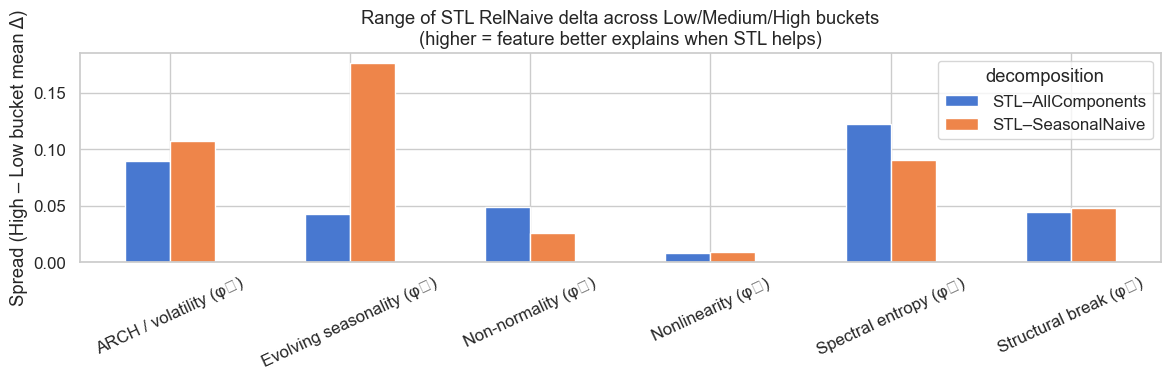

In [8]:
# Bar chart of delta spread per feature
fig, ax = plt.subplots(figsize=(12, 4))
pivot_spread = spread_df.pivot(index="feature", columns="decomposition", values="delta_spread")
pivot_spread.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Range of STL RelNaive delta across Low/Medium/High buckets\n(higher = feature better explains when STL helps)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25)
ax.set_ylabel("Spread (High – Low bucket mean Δ)")
fig.tight_layout()
plt.savefig(DATA / "fig_feature_spread.png", dpi=150, bbox_inches="tight")
plt.show()

## When Are Direct Models Preferable?

Per `(feature, bucket, frequency)`: fraction of model configurations where  
`without_stl` achieves lower RelNaive than both STL strategies.

c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\seaborn\utils.py:61: UserWarning: Gly

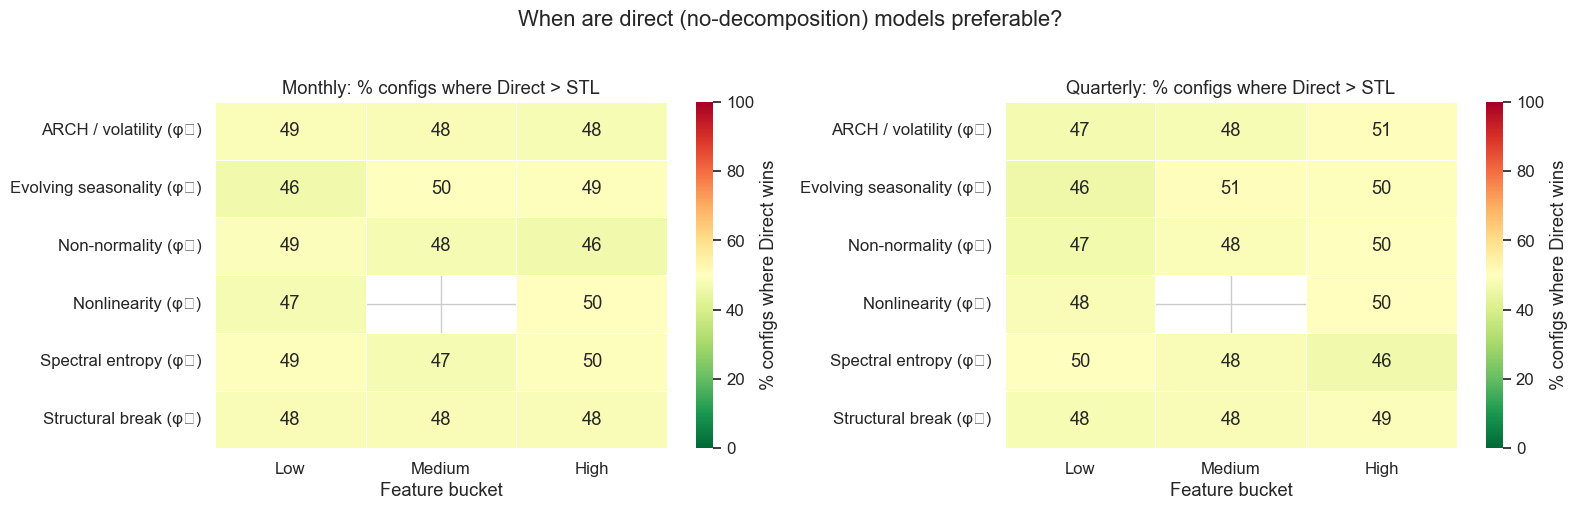

In [9]:
direct_pref = (
    stl_delta
    .groupby(["feature_name", "feature_bucket", "frequency", "decomposition_method"])["rn_delta"]
    .apply(lambda x: (x < 0).mean() * 100)  # pct where Direct is better
    .reset_index(name="pct_direct_better")
)

# Average over both STL strategies
direct_avg = (
    direct_pref
    .groupby(["feature_name", "feature_bucket", "frequency"])["pct_direct_better"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
for ax, freq in zip(axes, ["monthly", "quarterly"]):
    sub = direct_avg[direct_avg["frequency"] == freq]
    if sub.empty:
        ax.set_visible(False)
        continue
    pivot = sub.pivot(index="feature_name", columns="feature_bucket", values="pct_direct_better")
    pivot = pivot.reindex(columns=BUCKET_ORDER)
    pivot.index = [FEATURE_LABELS.get(f, f) for f in pivot.index]
    sns.heatmap(
        pivot, annot=True, fmt=".0f", vmin=0, vmax=100,
        cmap="RdYlGn_r", linewidths=0.5, ax=ax,
        cbar_kws={"label": "% configs where Direct wins"}
    )
    ax.set_title(f"{freq.capitalize()}: % configs where Direct > STL")
    ax.set_xlabel("Feature bucket")
    ax.set_ylabel("")

fig.suptitle("When are direct (no-decomposition) models preferable?", y=1.02)
fig.tight_layout()
plt.savefig(DATA / "fig_direct_preferred.png", dpi=150, bbox_inches="tight")
plt.show()